Next we shall solve for a polynomial solution given by :

$$ y(x) = x^4 + 3x^2 + 1 $$

The ODE to feed to the neural net is :

$$ \dfrac{d^2y}{dx^2} = 12x^2+6 $$

with IC(s) : 

$$ y(0) = 1 $$
$$ y'(0) = 0 $$

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
# Deciding on the domain
N = 101
x = torch.linspace(-2.0,2.0,N,requires_grad=True).reshape(-1,1)

In [3]:
# Defining the model
model = nn.Sequential(
    nn.Linear(1,20),
    nn.Tanh(),
    nn.Linear(20,20),
    nn.Tanh(),
    nn.Linear(20,1)
)

In [4]:
# Loss function
def Loss(model, x):
    y = model(x)

    # gradient terms
    # first derivative
    dydx = torch.autograd.grad(
        outputs=y,
        inputs=x,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]
    # second derivative
    d2ydx2 = torch.autograd.grad(
        outputs=dydx,
        inputs=x,
        grad_outputs=torch.ones_like(dydx),
        create_graph=True
    )[0]

    # IC Loss
    loss_IC = (y[N//2]-1)**2 + (dydx[N//2])**2

    # ODE Loss
    loss_ODE = torch.mean((d2ydx2 - 12*x**2 - 6)**2)

    # total loss
    loss = loss_IC + loss_ODE
    return loss

In [5]:
# testing the loss function
Loss(model, torch.linspace(-2.0,2.0,N,requires_grad=True).reshape(-1,1))

tensor([712.5135], grad_fn=<AddBackward0>)

In [6]:
# Optimizer
optim = torch.optim.Adam(model.parameters(),lr = 0.001)

In [7]:
# Training the PINN
N_epochs = 100000
loss_arr = []

for epoch in range(N_epochs):
    # feed forward and loss term
    loss = Loss(model,x)
    loss_arr.append(loss.item())

    # optimization
    loss.backward()
    optim.step()
    optim.zero_grad()

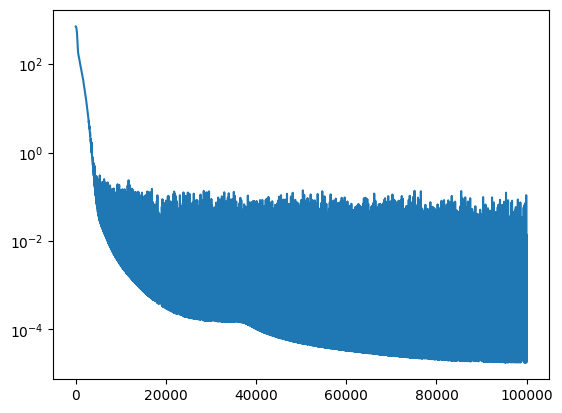

In [8]:
plt.semilogy(loss_arr)
plt.show()

In [9]:
# exact function
y_exact = x**4 + 3*x**2 + 1

# PINN function
with torch.no_grad():
    y_PINN = model(x)

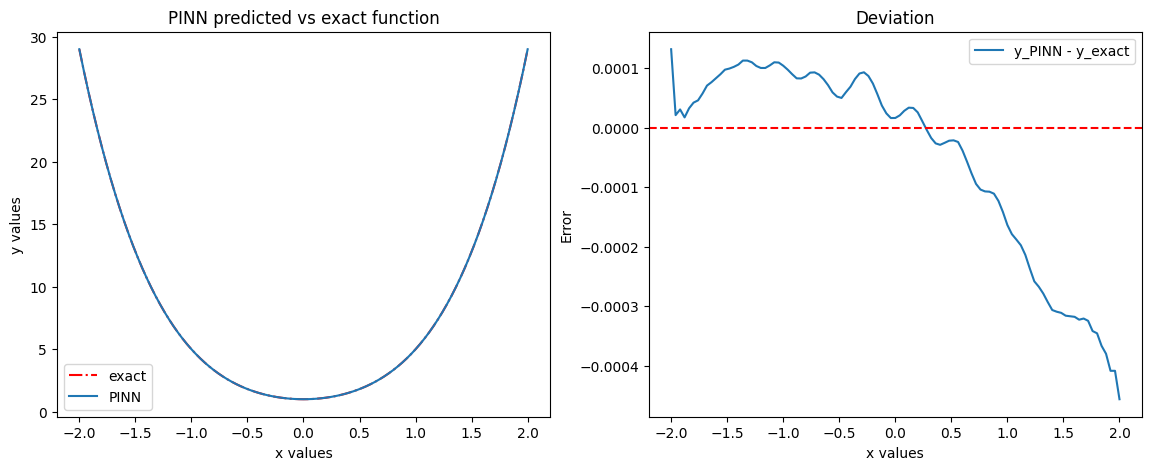

In [10]:
# comparing the PINN against the exact function
plt.figure(figsize = (14,5))

plt.subplot(1,2,1)
plt.plot(x.flatten().detach(),y_exact.flatten().detach(),c = 'red',ls = '-.',label = 'exact')
plt.plot(x.flatten().detach(),y_PINN.flatten().detach(),label = 'PINN')
plt.legend()
plt.title("PINN predicted vs exact function")
plt.xlabel("x values")
plt.ylabel("y values")

plt.subplot(1,2,2)
plt.plot(x.flatten().detach(),(y_PINN-y_exact).flatten().detach(),label = f'y_PINN - y_exact')
plt.axhline(0,ls = '--',c = 'red')
plt.legend()
plt.title("Deviation")
plt.xlabel("x values")
plt.ylabel("Error")
plt.show()

### Remarks :

1. It is observed that increasing the total number of points, i.e. N, in the domain dramatically improves the training for same number of epochs, learning rate. Even the time taken to train the model increases at a rate far less than what one would expect on increasing N_epochs.

Try comparing : N = 21, 101

2. Training the model freshly every time, we sometimes see that the trained model doesn't always reach the same level of accuracy as other times.

3. ReLU activation completely fails to learn the function. It just satisfies the BCs and nothing more.